<a href="https://colab.research.google.com/github/BastianRu/Deep-Learning-Foundations-From-Scratch-Journal/blob/main/02-Character-Level_Language_Models/CharacterLevelLanguageModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loading the dataset (src=https://github.com/karpathy/makemore/blob/master/names.txt)

###Multinomial Sampling with Pytorch

In [ ]:
import torch

#Note: We can use a torch generator to always get deterministic samples.
#But it only works if it's initialized every time you use torch.multinomial
#Even though, it's still 100% deterministic. If you iterate torch.multinomial, you'll get
#exactly the same numbers
g = torch.Generator().manual_seed(41)

ix = torch.multinomial(torch.Tensor([0.7, 0.3, 0.1]), 10, replacement=True, generator=g)

#It produces indices according to the probabilities given in the probs tensor.
#The "replacement" parameter is something you must be careful with. If it is false (the default),
#each index can only be drawn once, meaning there will be no repeated indices in the output.
#Because of this, you cannot set num_samples > len(probs), since the function would run out
# of eligible indices, which is undesirable for our task.

lxi = list(ix)

counts = {}
for x in lxi:
  counts[x.item()] = counts.get(x.item(), 0) + 1

print(ix)



RuntimeError: cannot sample n_sample > prob_dist.size(-1) samples without replacement

Here's an example working with a bigram character level lenguage model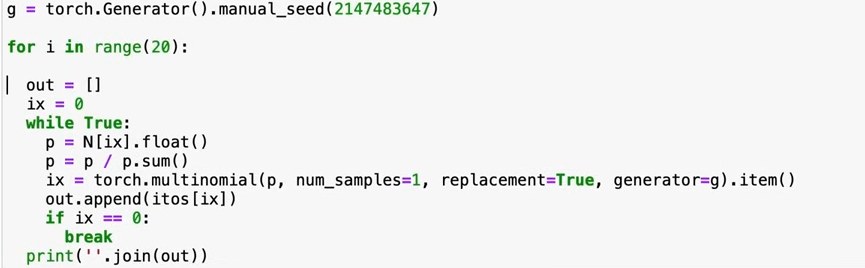

###Getting a probability distribution

In [ ]:
import random

#Get a random number array whose numbers represent some kind of data frecuency
counts = torch.Tensor([random.uniform(1, 100) for _ in range(5)]).int()

#Each number is divided by the summatory of all the numbers
#And we'll get a nice probability distribution
probabilities = counts/counts.sum()

#All the props must sum up to 1
probabilities.sum()

for p in probabilities:
  print(p)


tensor(0.2102)
tensor(0.2644)
tensor(0.1390)
tensor(0.1729)
tensor(0.2136)


###Matrix Broadcasting and some tensorial Algebra


In [ ]:
#Let's say we got a matrix of counts
#And we want to get a probability distribution just as same as before
#But instead of having just a single list of probs, we got a matrix
#We want another matrix in which each row is the prop distribution of the original matrix rows

g = torch.Generator().manual_seed(41) #To keep it deterministic

pN = torch.rand(5, 5, generator=g)
N = (pN*100).int()
#You can also add a smoothing component which is just a number additioned to all the counts (or logits in nns) and that's going to
#give you a more uniform distribution (probabilities will become closer to each other)

print(N)
#We use dim parameter to sum over rows not colums
#And keepdim allows us to not squeeze out the dimensions since by default is false
#And that's going to give us the row sums
sums = N.sum(dim=1, keepdim=True)

#Now we want to multiply each element from the original matrix with its respective value

#The broadcasting allows us to do that, and here are its rules:
# 1.Each tensor has at least one dimension.
# 2.When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.
# N is 5x5 while sums is 5x1 (column vector where every subvector has one element). 5 = 5, and for the second dimension one of them is 1
P = N / sums
P*100


tensor([[23, 22, 80, 16, 26],
        [77, 12, 74, 80, 63],
        [58, 69, 87, 54, 14],
        [96, 86, 48, 20, 30],
        [ 5, 83, 45, 84, 68]], dtype=torch.int32)


tensor([[13.7725, 13.1737, 47.9042,  9.5808, 15.5689],
        [25.1634,  3.9216, 24.1830, 26.1438, 20.5882],
        [20.5674, 24.4681, 30.8511, 19.1489,  4.9645],
        [34.2857, 30.7143, 17.1429,  7.1429, 10.7143],
        [ 1.7544, 29.1228, 15.7895, 29.4737, 23.8596]])

In [ ]:
#Just the itos and stoi dictionaries definition

chars = ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

stoi  = { s:i for i, s in enumerate(chars)}
itos = { i:s for s, i in stoi.items()}


###The negative log likelihood loss function

In [ ]:
import torch.nn.functional as F
#As we work with secuences (of characteres in this case), we want to use a proper loss function for this
#The likelihood is the probability that the model assigns
# to the observed sequence
#The more high is the likelihood the better the model performs


#If we got the following probs

example_names = ['emma', 'olivia','ava','isabella','sophia','charlotte','mia','amelia','harper', 'evelyn']

xs, ys = [], [] #xs = inputs, ys = expected outputs (labels)

for w in example_names[:1]:
  w = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(w, w[1:]):
    xs.append(stoi[ch1])
    ys.append(stoi[ch2])
   # print(ch1)

#NN weights
g = torch.Generator().manual_seed(2147483647)
W = torch.randn(27, 27, generator=g) #27 weights per neuron (27 inputs from the input layer) (27 neuron) (x = nin, y = nouts)

#One-hot encoding
xenc = F.one_hot(torch.tensor(xs), num_classes=27).float()

# Matrix multiplication (be careful with the order)
logits = xenc @ W #pre-activation values, commonly called logits (log-counts)
#Activation function: Softmax
counts = logits.exp() #exponentiate all the logits
probs = counts / counts.sum(1, keepdim=True) #convert into a probability distribution
#print(counts)

#Now we're finally ready to compute the loss :'

#Likelihood is defined as the product of all the probabilities assigned by the model to a correct secuence
#But that's going to give us such a tiny numbers, instead of that we use the log likelihood
#log(likelihood) = log(prop1*prop2*prop3*...propn) = log(prop1) + log(prop2) + log(prop3) + ... log(propn)

llh = probs[torch.arange(len(xs)), torch.tensor(ys)].log().mean() #We're summing up and calculing the average of that sum

#If the log likelihood is high (close to zero) means that probabilities for the correct labels (predictiosn) are high which is desirable
#But a loss function is something that we'd like to minimize not maximize so we use the negative of the log likelihood
loss = -llh

xs


[0, 5, 13, 13, 1]

###Predicting the next character in a secuenc, e.g. names

In [ ]:
#We're going to use this approach to implement a model which predicts the next character in a name (Character level languague model)

#Loading the entire dataset

!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt -O names.txt #names source

# Load the names from the downloaded file
with open('names.txt', 'r') as f:
    names = f.read().splitlines()

xs, ys = [], [] #xs = inputs, ys = expected outputs (labels)

for w in names:
  w = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(w, w[1:]):
    xs.append(stoi[ch1])
    ys.append(stoi[ch2])
    #print(ch1)
xs = torch.tensor(xs)
ys = torch.tensor(ys)



# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

#One-hot
xenc = F.one_hot(xs, num_classes=27).float()

num = xs.nelement()
num

--2026-01-22 16:09:25--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-01-22 16:09:26 (8.11 MB/s) - ‘names.txt’ saved [228145/228145]



228146

###Training cycle

In [ ]:
#training cycle

for i in range(100):
  #forward pass

  logits = xenc @ W #feed forward
  counts = logits.exp() #softmax
  probs = counts / counts.sum(dim=1, keepdim=True)

  #loss
  W.grad = None # set to zero the gradient (None is the right way to do it)
  #Here's an important point to keep into account. We can use mean error
  #which is the moderm standar way to work with errors, if we use the average instead of just the sum
  #The gradient will be independent from the number of examples, and we have no need to re-tune the learning rate
  #as it happens with just the sum
  loss = -probs[torch.arange(len(xs)), ys].log().mean() + 0.01*(W**2).mean() #last term is called "regularization"
  #and it's equivalent to model smoothing in stastical ML
  loss.backward()
  if i%1 == 0: print(loss.item())

  #backward pass
  W.data += -50*W.grad #We're using tensors, this is their magic



3.7686190605163574
3.3788065910339355
3.16109037399292
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188303470611572


In [ ]:
#Sampling from the trained model

g = torch.Generator().manual_seed(2147483647) #to always get the same examples

ix = 0
#We can sample as many examples as we want
for i in range(10):
  w = ''
  while True:
    xenco = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    #print(xenc)

    #forward pass (Not using the same names as before)
    l = xenco @ W
    c = l.exp()
    p = c / c.sum(dim=1, keepdim=True)
    #print(probs)

    #sampling
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    w += itos[ix]

    if ix == 0: break
  print(w)

#The results?
#Compared to a completely uniform distribution over all bigrams which would produce purely random character secuences, our model has learned, in some way, how to
#build name-like strings using the probabilties matrix (our tuned weights)

dexzmalegllusailezktxha.
kllimittain.
lgdan.
ka.
da.
st.
zvpucjalhrigmtop.
mbliellavugkwpteda.
ka.
eria.


WORK IN PROGRESS...